# TP1 — Ingesta y exploración de datos GDELT 2.0

**IMPORTANTE:** Al utilizar herramientas de inteligencia artificial deben indicar qué IA están usando y con qué propósito. Por ejemplo: "Claude Opus 4.6" para "mejorar redacción de textos" o "Chat GPT 5.6" para "crear código fuente".

Analicen los eventos registrados en todo el mundo a partir del proyecto GDELT: https://blog.gdeltproject.org/gdelt-2-0-our-global-world-in-realtime/

## Recursos

- Lista de URLs con actualizaciones cada 15 minutos: https://data.gdeltproject.org/gdeltv2/masterfilelist.txt
- URL oficial del libro de códigos de GDELT 2.0: https://data.gdeltproject.org/documentation/GDELT-Event_Codebook-V2.0.pdf
- URL de la documentación en texto/HTML donde se enuncian los campos (CAMEO Manual): https://gdeltproject.org/data/documentation/CAMEO.Manual.1.1b3.pdf

## Actividades

1) Accedan a los datos de la forma más eficiente posible. Fundamenten sus decisiones.

2) Calculen las siguientes medidas diarias desde 2 Sep 2026:
   - Cantidad de eventos en el día
   - Promedio de artículos por evento en el día
   - Promedio de fuentes por evento en el día

3) Presenten los resultados como un DataFrame de Pandas.

## Formato de entrega

Notebook con el nombre "TP1" dentro de su repositorio GitHub. En esta actividad deben pegar la URL con el acceso a la notebook.


---

**Autora:** Aylin Agatha Vazquez Chenlo — Doctorado en Ingeniería, ITBA (bioingeniera)

**Profesor:** Nicolás Guillermo Tripp

**Repositorio:** https://github.com/aylinavch/ITBA-Introduccion-Ingenieria-de-Datos

**Utilización de IA para co-desarrollo:** Se utilizó **Claude Sonnet 5** (Anthropic) para

- Estructurar el pipeline de descarga paralela e ingesta de los archivos de GDELT 2.0 directamente desde ZIP en memoria.

- Corregir la redacción de las explicaciones/justificaciones en las celdas markdown del notebook.

---

## 1) Acceso a los datos: decisiones y justificación

GDELT 2.0 no ofrece una API REST que devuelva agregados como "cantidad de eventos por día" o promedios de `NumArticles`/`NumSources`. Las vías de acceso reales son:

- **Archivos crudos `*.export.CSV.zip`** (los que use acá): Se publican cada 15 minutos y están listados en `masterfilelist.txt`. Es el dataset de eventos en bruto, una fila por evento, con todos los campos definidos en el *Event Codebook V2.0*.

- **GDELT en BigQuery** (`gdelt-bq.gdeltv2.events`): Permitiría hacer el `GROUP BY` con SQL sin descargar nada, pero requiere una cuenta de Google Cloud con billing configurado y procesa volúmenes de datos que pueden generar costo fuera del free tier. No es un acceso "abierto" equivalente al anterior.

- **GDELT DOC API / GEO API**: Sirven para búsqueda de texto sobre artículos (tono, temas, geolocalización de menciones), pero **no** exponen `NumSources` ni `NumArticles` agregados por evento/día. No ayudarían a resolver esta consigna.

Como la consigna pide específicamente `NumArticles` y `NumSources` a nivel evento, agregados por día, la opción sin depender de credenciales de terceros es descargar los archivos de eventos. Para que sea factible y **lo más eficiente posible**:

1. Se lee `masterfilelist.txt` una única vez y se filtran las URLs por el timestamp `YYYYMMDDHHMMSS` embebido en el nombre del archivo, quedándonos solo con los ~96 archivos/día del rango pedido (no se descarga todo el histórico).
2. La descarga se hace **en paralelo** con `ThreadPoolExecutor`, ya que cada archivo es independiente y el servidor de GDELT soporta múltiples conexiones concurrentes.
3. Cada archivo se lee **directamente desde el ZIP en memoria** (`BytesIO` + `pandas.read_csv(..., compression="zip")`), sin escribir nada a disco — evita I/O innecesario y pasos manuales de descompresión.
4. Los archivos `.export.CSV.zip` son en realidad **tab-delimited** (`sep="\t"`) aunque el nombre diga "CSV", según el Event Codebook V2.0; además no traen encabezado, por lo que se nombran las 61 columnas manualmente.

### Rango de fechas

La consigna pide las métricas "desde el 2 de septiembre de 2026". Como hoy es 10/09/2026 y el día en curso está incompleto, se calculó el rango **2026-09-02 a 2026-09-09** (últimos días completos disponibles).

In [1]:
import pandas as pd
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import BytesIO

# Columnas oficiales del Event Codebook V2.0 (los .export.CSV.zip no traen encabezado)
COLUMNS = [
    "GlobalEventID", "Day", "MonthYear", "Year", "FractionDate",
    "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
    "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
    "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
    "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
    "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode",
    "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles",
    "AvgTone",
    "Actor1Geo_Type", "Actor1Geo_FullName", "Actor1Geo_CountryCode",
    "Actor1Geo_ADM1Code", "Actor1Geo_ADM2Code", "Actor1Geo_Lat",
    "Actor1Geo_Long", "Actor1Geo_FeatureID",
    "Actor2Geo_Type", "Actor2Geo_FullName", "Actor2Geo_CountryCode",
    "Actor2Geo_ADM1Code", "Actor2Geo_ADM2Code", "Actor2Geo_Lat",
    "Actor2Geo_Long", "Actor2Geo_FeatureID",
    "ActionGeo_Type", "ActionGeo_FullName", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_ADM2Code", "ActionGeo_Lat",
    "ActionGeo_Long", "ActionGeo_FeatureID",
    "DATEADDED", "SOURCEURL"
]

In [2]:
url_master = "https://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

master = pd.read_csv(
    url_master,
    sep=" ",
    header=None,
    names=["size", "hash", "url"],
    low_memory=False,
)

fecha_ini = "20260902"
fecha_fin = "20260909"  # último día completo disponible (hoy es 2026-09-10)

urls = master[
    master["url"].str.endswith(".export.CSV.zip")
    & master["url"].str.extract(r"(\d{8})")[0].between(fecha_ini, fecha_fin)
]["url"].tolist()

print(f"Archivos a descargar: {len(urls)}")
for u in urls[:3]:
    print(" ", u)

Archivos a descargar: 768
  http://data.gdeltproject.org/gdeltv2/20260902000000.export.CSV.zip
  http://data.gdeltproject.org/gdeltv2/20260902001500.export.CSV.zip
  http://data.gdeltproject.org/gdeltv2/20260902003000.export.CSV.zip


In [3]:
def leer(url):
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return pd.read_csv(
        BytesIO(r.content),
        sep="\t",
        header=None,
        names=COLUMNS,
        compression="zip",
        low_memory=False,
        quoting=3,  # evita problemas con comillas sueltas dentro de las URLs de origen
    )

dfs, errores = [], []
with ThreadPoolExecutor(max_workers=20) as ex:
    futuros = {ex.submit(leer, u): u for u in urls}
    for fut in as_completed(futuros):
        try:
            dfs.append(fut.result())
        except Exception as e:
            errores.append((futuros[fut], str(e)))

print(f"Archivos leídos OK: {len(dfs)}  |  errores: {len(errores)}")

df = pd.concat(dfs, ignore_index=True)
print("Eventos totales (crudo, todas las fechas mencionadas):", len(df))
df[["GlobalEventID", "Day", "EventCode", "NumMentions", "NumSources", "NumArticles", "AvgTone", "ActionGeo_FullName"]].head()

Archivos leídos OK: 768  |  errores: 0
Eventos totales (crudo, todas las fechas mencionadas): 791519


,GlobalEventID,Day,EventCode,NumMentions,NumSources,NumArticles,AvgTone,ActionGeo_FullName
0,1321026125,20260803,311,4,2,4,3.389328,"Bishkek, Bishkek, Kyrgyzstan"
1,1321026126,20260902,42,2,1,2,-0.889454,South Africa
2,1321026127,20260902,36,5,1,5,0.704225,NaN
3,1321026128,20260902,40,3,1,3,-2.020202,"Lake Ontario, New York, United States"
4,1321026129,20260902,42,10,1,10,-0.868307,"Central Valley, California, United States"


> **Nota:** el campo `Day` es la fecha en que *ocurrió* el evento, no la fecha del archivo. Un archivo publicado el 02/09/2026 puede contener eventos con `Day` de meses o años anteriores, porque GDELT registra en cada corrida menciones a hechos pasados que aparecen citados en noticias actuales (por ejemplo la fila con `Day = 20260803` de arriba). Por eso en el paso siguiente filtramos explícitamente por `Day` dentro del rango pedido, en lugar de asumir que "archivo del día X" = "eventos del día X".

In [5]:
df.shape, df.columns

((791519, 61),
 Index(['GlobalEventID', 'Day', 'MonthYear', 'Year', 'FractionDate',
        'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1KnownGroupCode',
        'Actor1EthnicCode', 'Actor1Religion1Code', 'Actor1Religion2Code',
        'Actor1Type1Code', 'Actor1Type2Code', 'Actor1Type3Code', 'Actor2Code',
        'Actor2Name', 'Actor2CountryCode', 'Actor2KnownGroupCode',
        'Actor2EthnicCode', 'Actor2Religion1Code', 'Actor2Religion2Code',
        'Actor2Type1Code', 'Actor2Type2Code', 'Actor2Type3Code', 'IsRootEvent',
        'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass',
        'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
        'Actor1Geo_Type', 'Actor1Geo_FullName', 'Actor1Geo_CountryCode',
        'Actor1Geo_ADM1Code', 'Actor1Geo_ADM2Code', 'Actor1Geo_Lat',
        'Actor1Geo_Long', 'Actor1Geo_FeatureID', 'Actor2Geo_Type',
        'Actor2Geo_FullName', 'Actor2Geo_CountryCode', 'Actor2Geo_ADM1Code',
        'Actor2Geo_ADM2Cod

## 2) Métricas diarias (2 Sep 2026 en adelante)

Se agrupa por `Day` (fecha real del evento) y se calculan:
- **Cantidad de eventos**: `count` de `GlobalEventID`.
- **Promedio de artículos por evento**: media de `NumArticles` (cantidad total de artículos que mencionan el evento).
- **Promedio de fuentes por evento**: media de `NumSources` (cantidad de fuentes/medios distintos que lo reportan).

In [6]:
# Convertir Day (YYYYMMDD) a fecha real del evento
df["fecha"] = pd.to_datetime(df["Day"].astype(str), format="%Y%m%d").dt.date

# Me quedo solo con eventos cuya fecha real cae en el rango pedido (desde 2-Septiembre 2026)
mask = (df["fecha"] >= pd.to_datetime(fecha_ini).date()) & (df["fecha"] <= pd.to_datetime(fecha_fin).date())
df_filtrado = df[mask]

print("Eventos dentro del rango 2026-09-02 a 2026-09-09:", len(df_filtrado))

Eventos dentro del rango 2026-09-02 a 2026-09-09: 778201


## 3) Resultado: DataFrame de Pandas

Presento los resultados por fecha desde el 2 de Septiembre como:
- Cantidad de Eventos
- Promedio de articulos
- Promedio de Fuentes


In [7]:
resumen = (
    df_filtrado.groupby("fecha")
      .agg(
          Cantidad_Eventos=("GlobalEventID", "count"),
          Promedio_Articulos=("NumArticles", "mean"),
          Promedio_Fuentes=("NumSources", "mean"),
      )
      .round(3)
      .reset_index()
)

resumen

,fecha,Cantidad_Eventos,Promedio_Articulos,Promedio_Fuentes
0,2026-09-02,118700,4.645,1.048
1,2026-09-03,114819,4.638,1.045
2,2026-09-04,105007,4.696,1.046
3,2026-09-05,65800,4.652,1.040
4,2026-09-06,59604,4.579,1.044
5,2026-09-07,84639,4.684,1.039
6,2026-09-08,112860,4.611,1.048
7,2026-09-09,116772,4.632,1.042


## Gráfico: Cantidad de eventos por día

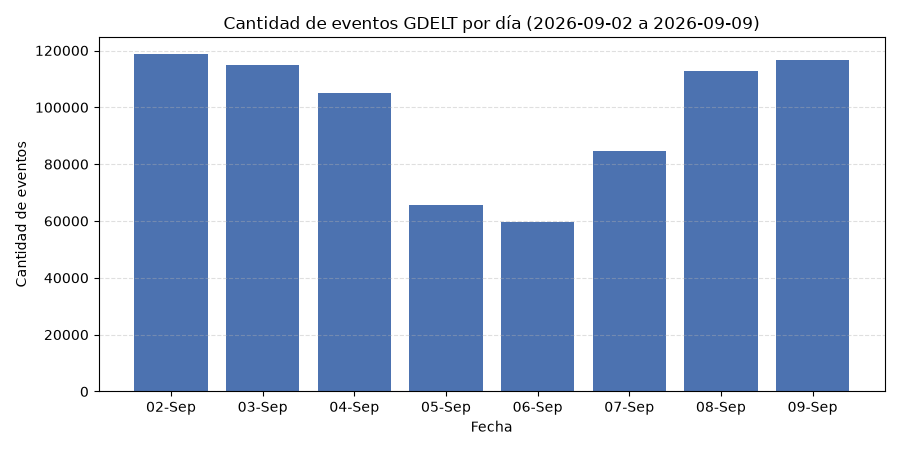

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(resumen["fecha"].astype(str), resumen["Cantidad_Eventos"], color="#4C72B0")
ax.set_title("Cantidad de eventos GDELT por día (2026-09-02 a 2026-09-09)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de eventos")
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

### Análisis rápido de los resultados

In [9]:
resumen['Promedio_Articulos'].mean(), resumen['Promedio_Fuentes'].mean()

(np.float64(4.642125), np.float64(1.044))

In [10]:
resumen['Cantidad_Eventos'].min(), resumen['Cantidad_Eventos'].max(), resumen['Cantidad_Eventos'].mean()

(np.int64(59604), np.int64(118700), np.float64(97275.125))

- El volumen de eventos diarios ronda entre ~60.000 y ~119.000, con una caída notoria el 5 y 6 de septiembre (fin de semana), consistente con que gran parte de la cobertura mediática (y por lo tanto de eventos detectados por GDELT) se concentra en días hábiles.
- El promedio de artículos por evento (~4.6–4.7) es sistemáticamente mayor al promedio de fuentes por evento (~1.04), lo cual tiene sentido: `NumArticles` cuenta menciones totales (incluyendo múltiples artículos del mismo medio o sindicados), mientras que `NumSources` cuenta dominios/fuentes distintas, que son naturalmente menos.

---
